# Polynomial Regression and Regularization

This notebook explores polynomial regression, a fundamental concept in machine learning for modeling non-linear relationships between variables. We will demonstrate how polynomial regression can lead to overfitting with increasing model complexity and introduce Ridge regularization as a technique to mitigate this issue.

In [1]:
import numpy as np

def make_sine_data(N=10, sigma=0.1):
    np.random.seed(0)
    x = np.linspace(0, 1, N)
    t_true = np.sin(2 * np.pi * x)
    noise = np.random.normal(0, sigma, size=N)
    t = t_true + noise

    return x, t_true, t

In [2]:
def design_matrix(x, M):
    return np.column_stack([x**j for j in range(M + 1)])

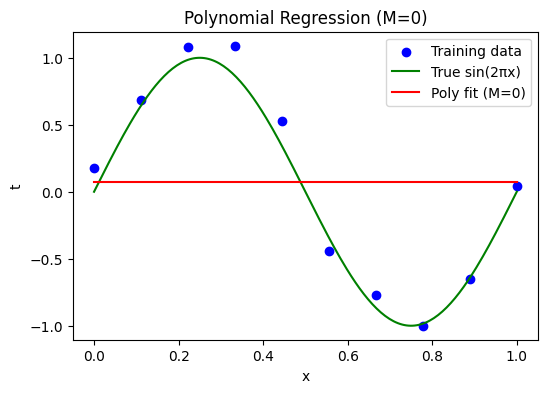

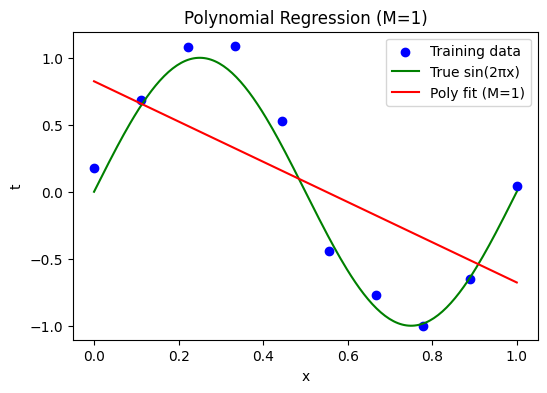

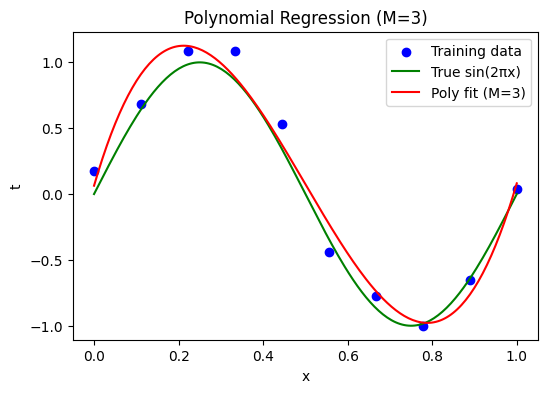

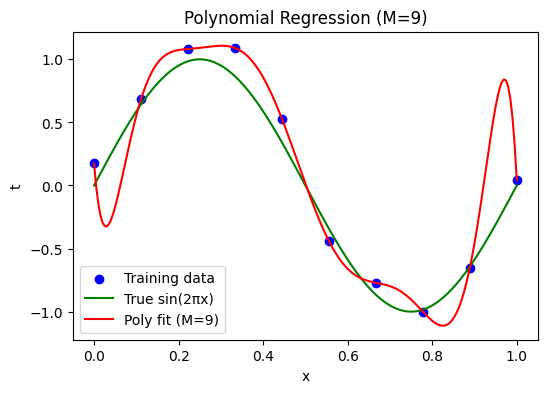

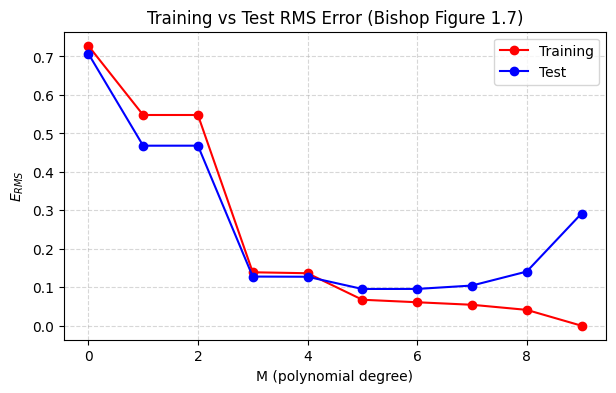

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def run_polynomial_regression(N=10, sigma=0.1):

    x, t_true, t = make_sine_data(N=N, sigma=sigma)

    x_test = np.linspace(0, 1, 200)
    y_test = np.sin(2 * np.pi * x_test)

    degrees = [0, 1, 3, 9]

    for M in degrees:

        Phi_train = design_matrix(x, M)
        Phi_test = design_matrix(x_test, M)

        w_star = np.linalg.solve(Phi_train.T @ Phi_train, Phi_train.T @ t)

        y_pred_test = Phi_test @ w_star

        plt.figure(figsize=(6, 4))
        plt.scatter(x, t, color='blue', label='Training data')
        plt.plot(x_test, y_test, color='green', label='True sin(2πx)')
        plt.plot(x_test, y_pred_test, color='red', label=f'Poly fit (M={M})')

        plt.xlabel("x")
        plt.ylabel("t")
        plt.title(f"Polynomial Regression (M={M})")
        plt.legend()
        plt.show()

def run_error_curves(N_train=10, N_test=100, sigma=0.1):

    x_train, t_true_train, t_train = make_sine_data(
        N=N_train, sigma=sigma
    )

    x_test = np.linspace(0, 1, N_test)
    t_test = np.sin(2 * np.pi * x_test)

    degrees = list(range(10))  # M = 0 ... 9
    train_rmse = []
    test_rmse = []

    for M in degrees:

        Phi_train = design_matrix(x_train, M)
        Phi_test = design_matrix(x_test, M)

        A = Phi_train.T @ Phi_train
        b = Phi_train.T @ t_train
        w_star = np.linalg.solve(A, b)

        y_train_pred = Phi_train @ w_star
        y_test_pred = Phi_test @ w_star

        train_rmse.append(
            np.sqrt(np.mean((y_train_pred - t_train)**2))
        )

        test_rmse.append(
            np.sqrt(np.mean((y_test_pred - t_test)**2))
        )

    plt.figure(figsize=(7, 4))
    plt.plot(degrees, train_rmse, 'o-', color='red', label='Training')
    plt.plot(degrees, test_rmse, 'o-', color='blue', label='Test')

    plt.xlabel("M (polynomial degree)")
    plt.ylabel(r"$E_{RMS}$")
    plt.title("Training vs Test RMS Error (Bishop Figure 1.7)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

run_polynomial_regression(N=10, sigma=0.1)
run_error_curves()


# Ridge Regularization

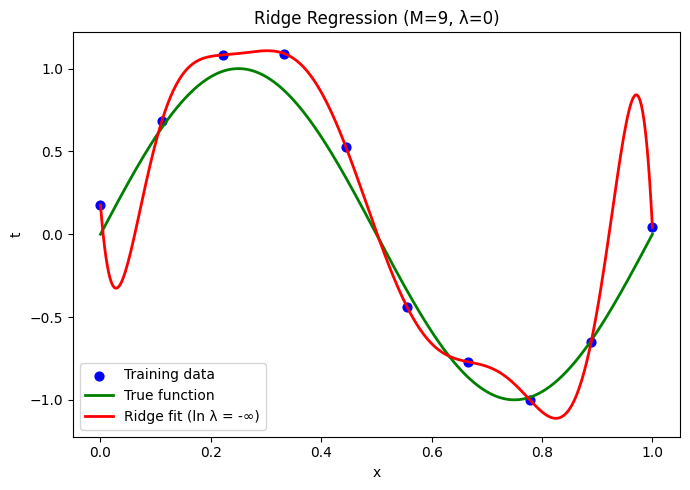

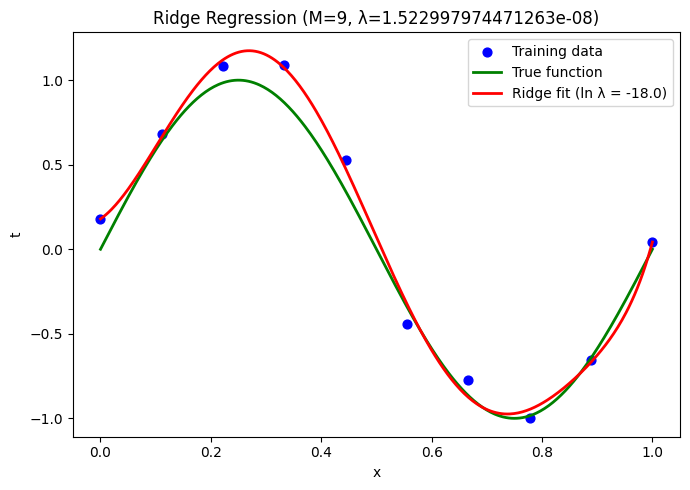

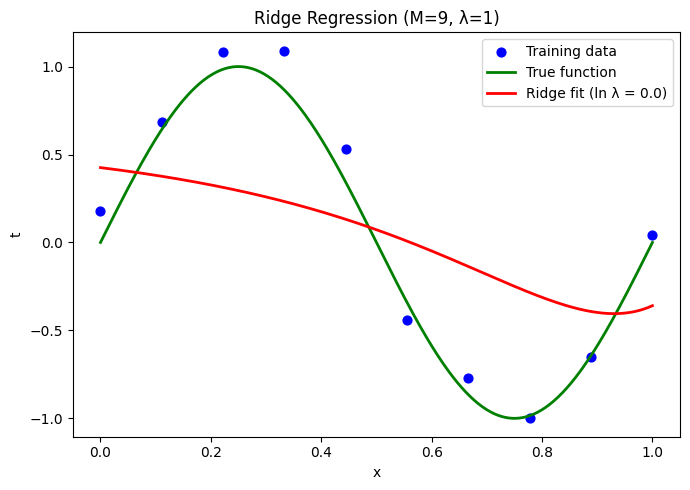

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def run_ridge_poly(N=10, sigma=0.1, M=9, lam=0, seed=42):

    x, t_true, t = make_sine_data(N=N, sigma=sigma)

    Phi = design_matrix(x, M)

    I = np.eye(M+1)
    A = Phi.T @ Phi + lam * I
    b = Phi.T @ t
    w = np.linalg.solve(A, b)

    x_test = np.linspace(0, 1, 400)
    Phi_test = design_matrix(x_test, M)
    y_pred = Phi_test @ w
    y_true = np.sin(2 * np.pi * x_test)

    plt.figure(figsize=(7,5))
    plt.scatter(x, t, color='blue', s=40, label='Training data')
    plt.plot(x_test, y_true, color='green', linewidth=2, label='True function')
    plt.plot(x_test, y_pred, color='red', linewidth=2,
             label=f'Ridge fit (ln λ = {np.log(lam) if lam>0 else "-∞"})')

    plt.xlabel("x")
    plt.ylabel("t")
    plt.legend()
    plt.title(f"Ridge Regression (M={M}, λ={lam})")
    plt.tight_layout()
    plt.show()

run_ridge_poly(N=10, sigma=0.1, M=9, lam=0)

# λ = exp(-18)
run_ridge_poly(N=10, sigma=0.1, M=9, lam=np.exp(-18))

# λ = 1
run_ridge_poly(N=10, sigma=0.1, M=9, lam=1)
